# Diabetes Dataset - Machine Learning Pipeline
This notebook trains, evaluates, and exports machine learning models to predict diabetes.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report


## 1. Load Dataset

In [2]:
# Define path
DATA_PATH = '../datasets/diabetes/diabetes_binary_health_indicators_BRFSS2015.csv'

# Load the dataset
print(f"Loading dataset from: {DATA_PATH}")
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
df.head()


Loading dataset from: ../datasets/diabetes/diabetes_binary_health_indicators_BRFSS2015.csv
Dataset shape: (253680, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


## 2. Train-Test Split & Features Identification

In [3]:
# Target and features
TARGET = 'Diabetes_binary'

X = df.drop(columns=[TARGET])
y = df[TARGET]

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")

# Identify categorical and numerical features
# In this dataset, all features are essentially numeric (binary or ordinal/continuous)
# However, we will treat multi-level numeric features as numerical for scaling
numerical_features = ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']
categorical_features = [col for col in X.columns if col not in numerical_features]

print(f"Numerical features ({len(numerical_features)}): {numerical_features}")
print(f"Categorical/Binary features ({len(categorical_features)}): {categorical_features}")


Train set: (202944, 21), Test set: (50736, 21)
Numerical features (7): ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']
Categorical/Binary features (14): ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']


## 3. Preprocessing

In [4]:
# We apply StandardScaler to numerical features.
# Binary/Categorical features (which are already 0/1 encoded in this dataset) can be passed through.

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', 'passthrough', categorical_features)
    ])

# Fit the preprocessor
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)


## 4. Model Training

In [5]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=-1)
}

trained_models = {}

print("Training models...")
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_preprocessed, y_train)
    trained_models[name] = model
print("Training complete!")


Training models...
Training Logistic Regression...


c:\Users\hp\django\MediSense\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Training Random Forest...
Training XGBoost...


c:\Users\hp\django\MediSense\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:37:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training complete!


## 5. Evaluation & Confusion Matrices

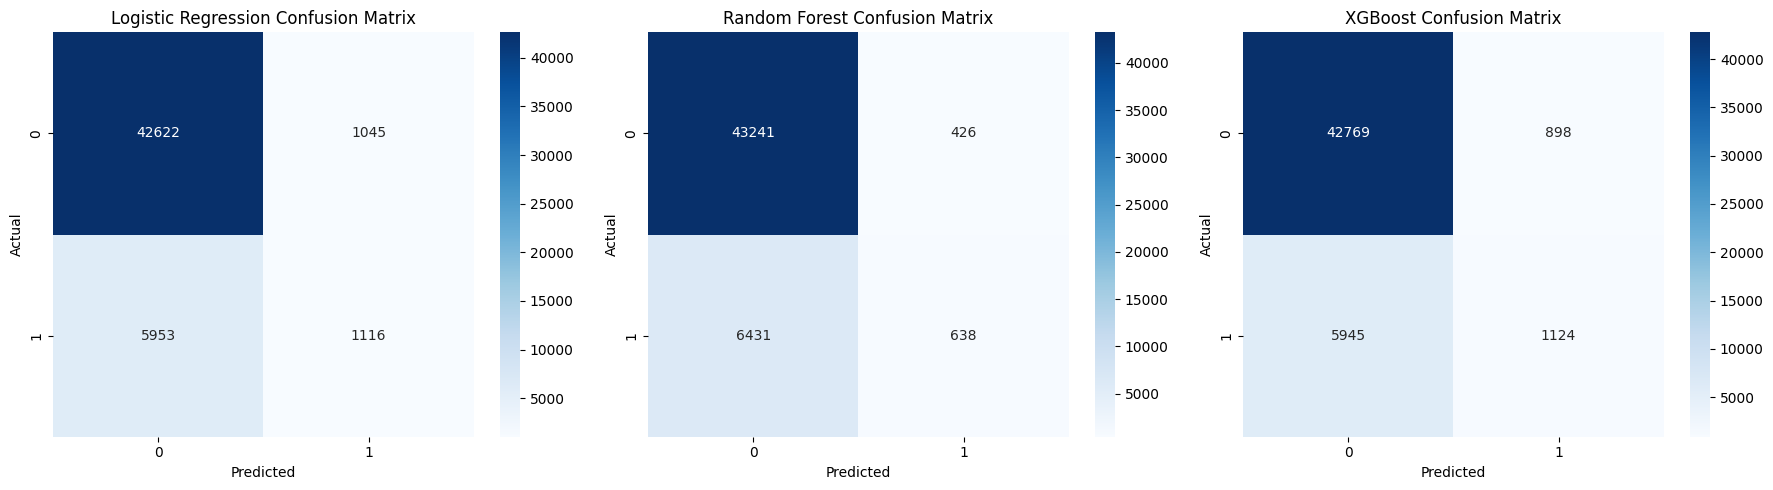

In [6]:
# Dictionary to store metrics
results = []

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(trained_models.items()):
    # Predictions
    y_pred = model.predict(X_test_preprocessed)
    y_prob = model.predict_proba(X_test_preprocessed)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'ROC AUC': roc_auc
    })
    
    # Confusion Matrix Plot
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()


## 6. Model Comparison & Best Model Selection

In [7]:
# Convert results to DataFrame for comparison
results_df = pd.DataFrame(results).set_index('Model')
display(results_df)

# We will select the best model based on ROC AUC (as data is slightly imbalanced and it's a good overall metric)
best_model_name = results_df['ROC AUC'].idxmax()
best_model = trained_models[best_model_name]

print(f"\nBest Model selected based on ROC AUC: **{best_model_name}**")


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
Logistic Regression,0.862070,0.516428,0.157872,0.241820,0.819230
Random Forest,0.864849,0.599624,0.090253,0.156892,0.821982
XGBoost,0.865125,0.555885,0.159004,0.247278,0.827396



Best Model selected based on ROC AUC: **XGBoost**


## 7. Save Best Model and Pipeline

In [8]:
# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# We can save a combined pipeline so that preprocessing and the model are bundled together
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', best_model)
])

# Save the full pipeline
model_path = '../models/diabetes_model.pkl'
joblib.dump(full_pipeline, model_path)
print(f"Successfully saved {best_model_name} pipeline to {model_path}")


Successfully saved XGBoost pipeline to ../models/diabetes_model.pkl


## 8. Feature Importance

C:\Users\hp\AppData\Local\Temp\ipykernel_5244\3268101372.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


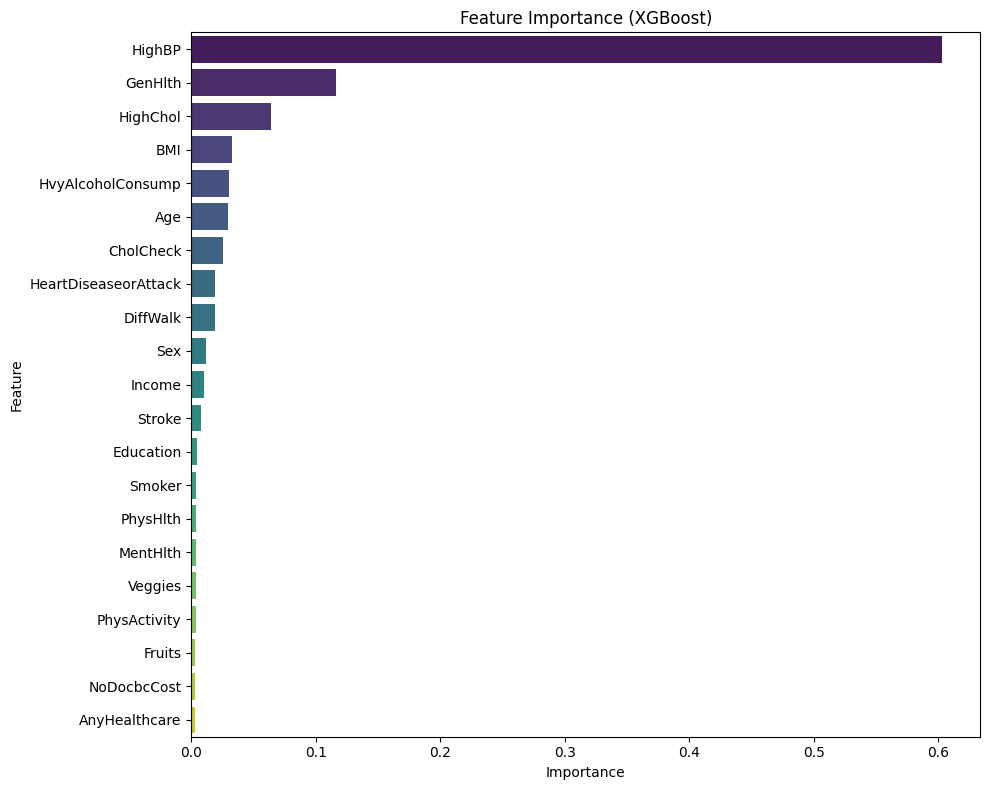

In [9]:
# Get feature names after preprocessing
# Numerical features come first, then categorical/passthrough features
feature_names = numerical_features + categorical_features

# Extract importance depending on the selected best model
if best_model_name == 'Logistic Regression':
    importances = best_model.coef_[0]
else:
    importances = best_model.feature_importances_

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.abs(importances)
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title(f'Feature Importance ({best_model_name})')
plt.tight_layout()
plt.show()
